In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [28]:
df = pd.read_csv('weight-height.csv')
df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


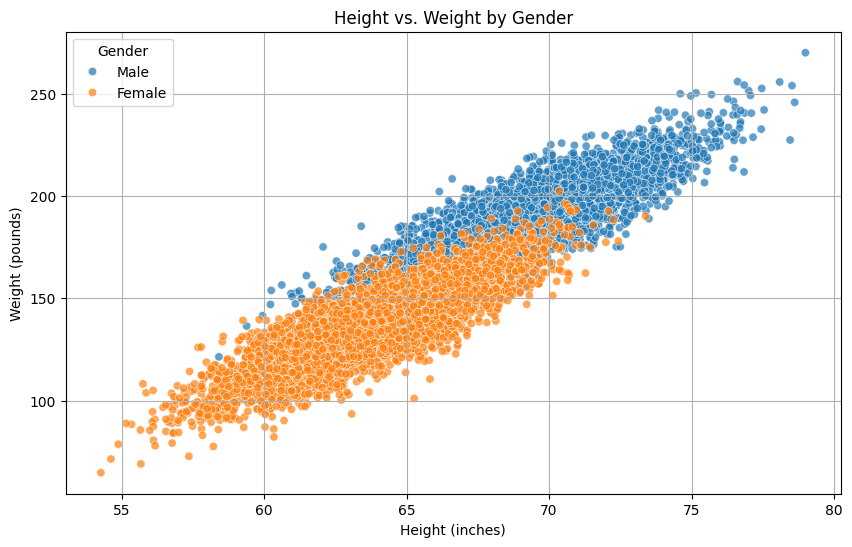

In [29]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Height', y='Weight', hue='Gender', alpha=0.7)
plt.title('Height vs. Weight by Gender')
plt.xlabel('Height (inches)')
plt.ylabel('Weight (pounds)')
plt.grid(True)
plt.show()

### Hierarchical Clustering

First, let's prepare the data for clustering. We'll select 'Height' and 'Weight' and scale them, as clustering algorithms are sensitive to the scale of features.

In [30]:
from sklearn.preprocessing import StandardScaler

# Select the features for clustering
X = df[['Height', 'Weight']]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data head:")
print(X_scaled[:5])

Scaled data head:
[[1.94406149 2.50579697]
 [0.62753668 0.02710064]
 [2.01244346 1.59780623]
 [1.39406046 1.82522245]
 [0.9134207  1.39875032]]


Now, we'll perform hierarchical clustering using the `ward` method, which minimizes the variance of the clusters being merged. We'll then visualize the results using a dendrogram.

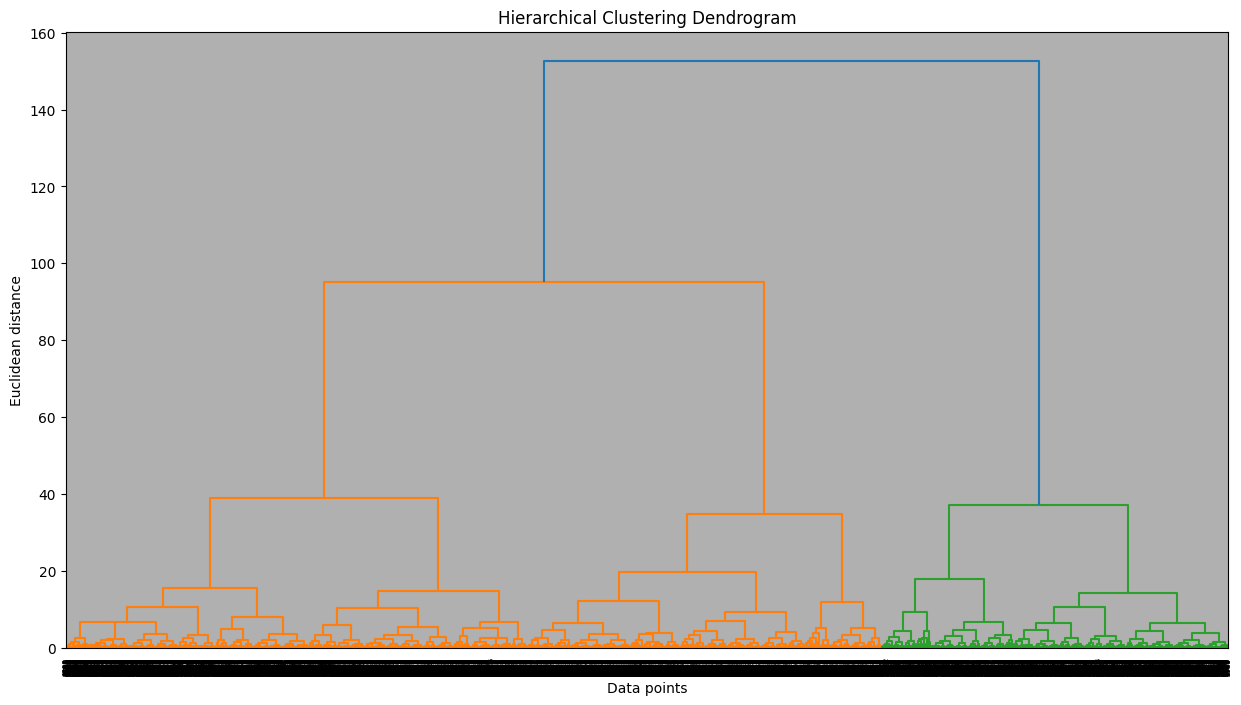

In [44]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Perform hierarchical clustering using 'ward' method
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(15, 8))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data points')
plt.ylabel('Euclidean distance')
plt.grid(True)
plt.show()

Based on the dendrogram, we can choose a number of clusters. A common approach is to look for the largest vertical distance that does not intersect any extended horizontal line. In this case, cutting the dendrogram at a certain height suggests 2 main clusters, which aligns with the gender split in our dataset.

In [45]:
from scipy.cluster.hierarchy import fcluster

# Apply hierarchical clustering to get cluster labels (e.g., 2 clusters)
# The 't' parameter is the threshold, and 'criterion' specifies how to use it.
# 'maxclust' means t is the number of clusters.
num_clusters = 2
clusters = fcluster(linked, num_clusters, criterion='maxclust')

# Add the cluster labels to the original DataFrame
df['Hierarchical_Cluster'] = clusters

print("Cluster distribution:")
print(df['Hierarchical_Cluster'].value_counts())
print("\nDataFrame head with clusters:")
print(df.head())

Cluster distribution:
Hierarchical_Cluster
2    7017
1    2983
Name: count, dtype: int64

DataFrame head with clusters:
  Gender     Height      Weight  Hierarchical_Cluster  Hierarchical_Cluster_4
0   Male  73.847017  241.893563                     1                       0
1   Male  68.781904  162.310473                     2                       1
2   Male  74.110105  212.740856                     1                       0
3   Male  71.730978  220.042470                     1                       0
4   Male  69.881796  206.349801                     1                       0


Let's visualize these clusters on the scatter plot to see how well they separate the data.

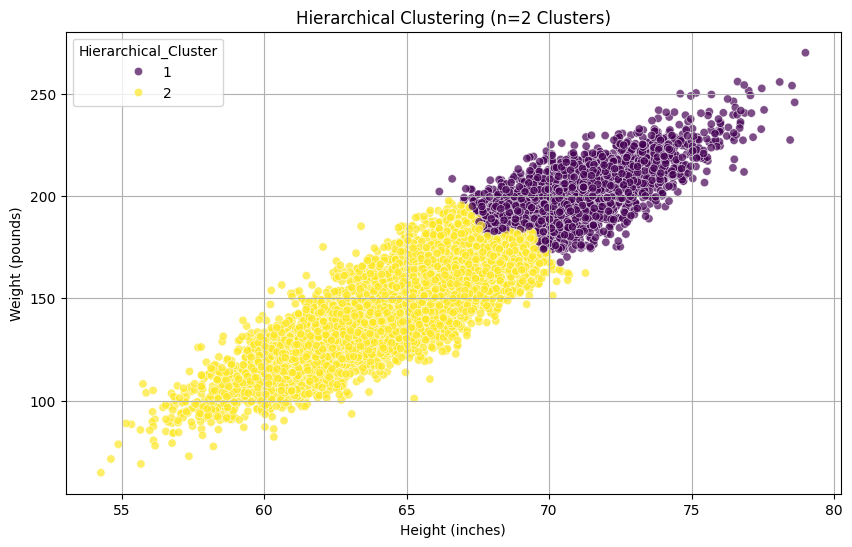

In [46]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Height', y='Weight', hue='Hierarchical_Cluster', palette='viridis', alpha=0.7)
plt.title(f'Hierarchical Clustering (n={num_clusters} Clusters)')
plt.xlabel('Height (inches)')
plt.ylabel('Weight (pounds)')
plt.grid(True)
plt.show()

 Hierarchical clustering has been successfully performed, and the results are visualized. We now have a more detailed view of the clusters within your data.

In [38]:
from sklearn.cluster import AgglomerativeClustering
Cluster = AgglomerativeClustering(n_clusters=4, linkage='ward') # Removed affinity='euclidean'
labels = Cluster.fit_predict(X_scaled)
df['Hierarchical_Cluster_4'] = labels # Add the new labels to the DataFrame

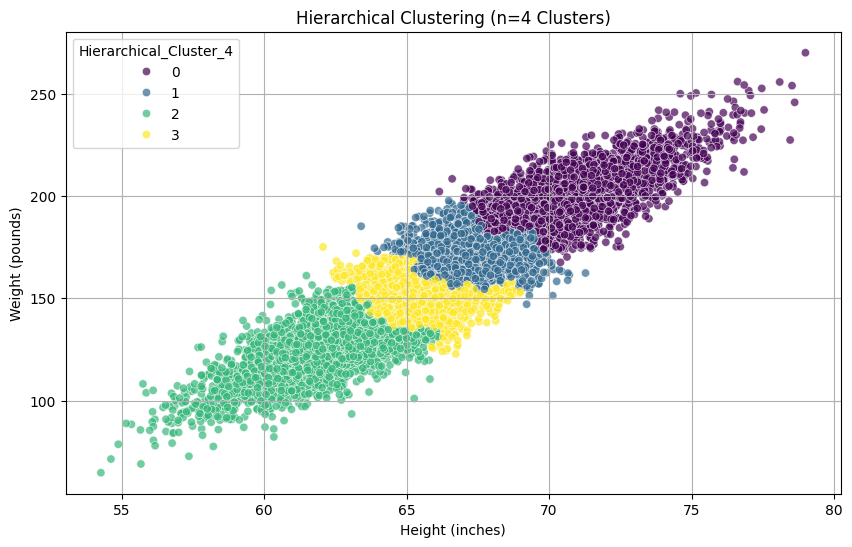

In [39]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Height', y='Weight', hue='Hierarchical_Cluster_4', palette='viridis', alpha=0.7)
plt.title('Hierarchical Clustering (n=4 Clusters)')
plt.xlabel('Height (inches)')
plt.ylabel('Weight (pounds)')
plt.grid(True)
plt.show()